# CommonLID Language Extension: CLD2 Evaluation

Analysis of experiments extending CLD2's language coverage across the CommonLID benchmark.
Goal: maximize **macro F1** and **micro F1** across all 89 evaluated languages.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Global font size scaling (1.5x)
plt.rcParams.update({
    'font.size': plt.rcParams['font.size'] * 1.5,
    'axes.titlesize': 'large',
    'axes.labelsize': 'medium',
    'xtick.labelsize': 'medium',
    'ytick.labelsize': 'medium',
    'legend.fontsize': 'medium',
})

# Load experiment results
df = pd.read_csv("results_lid.tsv", sep="\t")
for col in ["macro_f1", "micro_f1", "coverage"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Load baselines
baselines = pd.read_csv("results_baselines.tsv", sep="\t")
for col in ["macro_f1", "micro_f1", "coverage"]:
    baselines[col] = pd.to_numeric(baselines[col], errors="coerce")

# Load per-language results (from latest evaluation run)
lang_df = pd.read_csv("data/evaluation/results/per_language.tsv", sep="\t")

# Load confusion matrix
conf_df = pd.read_csv("data/evaluation/results/confusion.tsv", sep="\t")

print(f"Experiments: {len(df)}")
print(f"Languages evaluated: {len(lang_df[lang_df['n_samples'] > 0])}")
print(f"Baseline models: {list(baselines['model'])}")
df

Experiments: 29
Languages evaluated: 89
Baseline models: ['cld2-baseline', 'cld2-extended', 'glotlid', 'openlid-v3']


,commit,macro_f1,micro_f1,coverage,status,description
0,91040a9,0.4650,0.8694,1.0,keep,baseline (vanilla CLD2)
1,e19a6ad,0.4885,0.8818,1.0,keep,add kQuad_obj2 with 30 languages (32K buckets)
2,be2555e,0.5211,0.8810,1.0,keep,add PLang for 19 new langs + 128K bucket table
3,c980475,0.6015,0.8918,1.0,keep,dual-table scoring (both tables contribute hits)
4,b53bd18,0.6006,0.8905,1.0,keep,remove contrast filtering (simpler + better)
5,692b6bc,0.6921,0.8965,1.0,keep,switch to 0122 tables + focused table 2 (10K/l...
6,c8c0fba,0.7044,0.9175,1.0,keep,contrast filtering for table 2 against 0122 langs
7,d69afa8,0.7117,0.9249,1.0,keep,"5K quad/lang, remove pcm/guw/gom (high FP)"
8,6133642,0.7243,0.9262,1.0,keep,contrast threshold=1.0 (optimal)
9,4390008,0.7258,0.9261,1.0,keep,4K quad/lang + Latvian contrast (optimal)


## Metrics Over Experiments

Track how macro F1 and micro F1 evolve across 29 experiments.
Horizontal lines show GlotLID and OpenLID-v3 baseline performance.

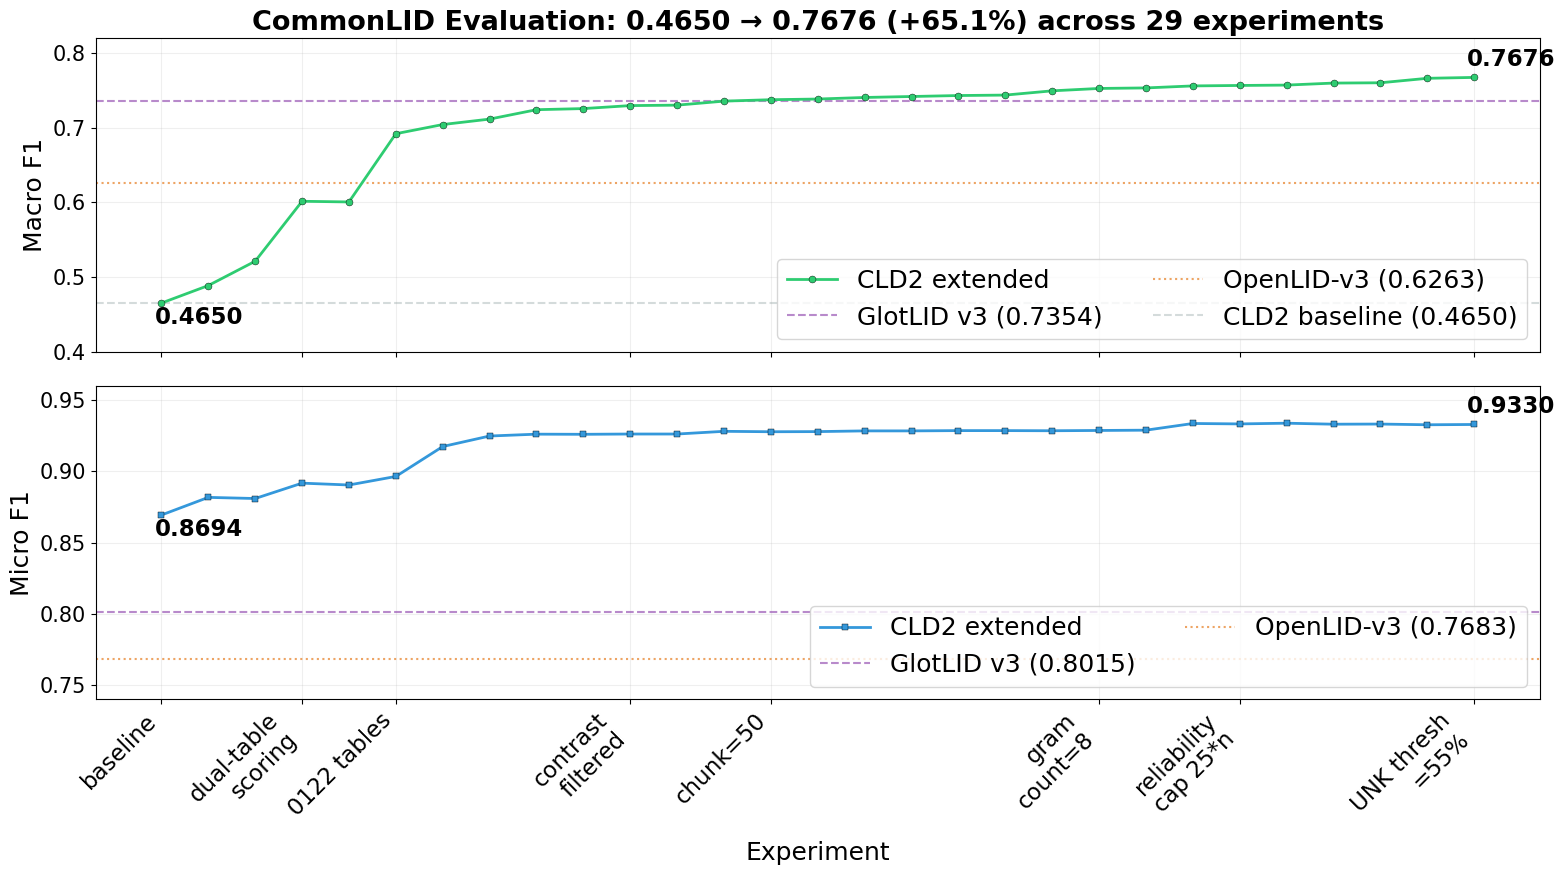

Saved to progress_lid.png


In [2]:
# Baseline values
glotlid_macro = baselines.loc[baselines['model'] == 'glotlid', 'macro_f1'].values[0]
glotlid_micro = baselines.loc[baselines['model'] == 'glotlid', 'micro_f1'].values[0]
openlid_macro = baselines.loc[baselines['model'] == 'openlid-v3', 'macro_f1'].values[0]
openlid_micro = baselines.loc[baselines['model'] == 'openlid-v3', 'micro_f1'].values[0]

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

x = range(len(df))

# Select major experiments for x-axis labels (every significant jump)
major_indices = [0, 3, 5, 10, 13, 20, 23, 28, len(df)-1]
major_indices = sorted(set(i for i in major_indices if i < len(df)))
major_labels = {
    0: "baseline",
    3: "dual-table\nscoring",
    5: "0122 tables",
    10: "contrast\nfiltered",
    13: "chunk=50",
    20: "gram\ncount=8",
    23: "reliability\ncap 25*n",
    28: "UNK thresh\n=55%",
}
# Make sure last experiment is labeled
last_idx = len(df) - 1
if last_idx not in major_labels:
    major_labels[last_idx] = "chunk=150"

# Macro F1
ax = axes[0]
ax.plot(x, df["macro_f1"], "o-", color="#2ecc71", linewidth=2, markersize=5,
        markeredgecolor="black", markeredgewidth=0.3, label="CLD2 extended", zorder=5)
ax.axhline(y=glotlid_macro, color="#9b59b6", linestyle="--", alpha=0.7, linewidth=1.5,
           label=f"GlotLID v3 ({glotlid_macro:.4f})")
ax.axhline(y=openlid_macro, color="#e67e22", linestyle=":", alpha=0.7, linewidth=1.5,
           label=f"OpenLID-v3 ({openlid_macro:.4f})")
ax.axhline(y=df.iloc[0]["macro_f1"], color="#95a5a6", linestyle="--", alpha=0.4,
           label=f"CLD2 baseline ({df.iloc[0]['macro_f1']:.4f})")
# Annotate first and last
ax.annotate(f"{df.iloc[0]['macro_f1']:.4f}", (0, df.iloc[0]['macro_f1']),
            textcoords="offset points", xytext=(-5, -15), fontsize=16.5, fontweight="bold")
ax.annotate(f"{df.iloc[-1]['macro_f1']:.4f}", (len(df)-1, df.iloc[-1]['macro_f1']),
            textcoords="offset points", xytext=(-5, 8), fontsize=16.5, fontweight="bold")
ax.set_ylabel("Macro F1", fontsize=18)
delta = df.iloc[-1]['macro_f1'] - df.iloc[0]['macro_f1']
pct = delta / df.iloc[0]['macro_f1'] * 100
ax.set_title(f"CommonLID Evaluation: {df.iloc[0]['macro_f1']:.4f} \u2192 {df.iloc[-1]['macro_f1']:.4f} "
             f"(+{pct:.1f}%) across {len(df)} experiments",
             fontsize=19.5, fontweight="bold")
ax.legend(loc="lower right", fontsize=18, ncol=2)
ax.grid(True, alpha=0.2)
ax.set_ylim(0.40, 0.82)

# Micro F1
ax = axes[1]
ax.plot(x, df["micro_f1"], "s-", color="#3498db", linewidth=2, markersize=5,
        markeredgecolor="black", markeredgewidth=0.3, label="CLD2 extended", zorder=5)
ax.axhline(y=glotlid_micro, color="#9b59b6", linestyle="--", alpha=0.7, linewidth=1.5,
           label=f"GlotLID v3 ({glotlid_micro:.4f})")
ax.axhline(y=openlid_micro, color="#e67e22", linestyle=":", alpha=0.7, linewidth=1.5,
           label=f"OpenLID-v3 ({openlid_micro:.4f})")
ax.annotate(f"{df.iloc[0]['micro_f1']:.4f}", (0, df.iloc[0]['micro_f1']),
            textcoords="offset points", xytext=(-5, -15), fontsize=16.5, fontweight="bold")
ax.annotate(f"{df.iloc[-1]['micro_f1']:.4f}", (len(df)-1, df.iloc[-1]['micro_f1']),
            textcoords="offset points", xytext=(-5, 8), fontsize=16.5, fontweight="bold")
ax.set_ylabel("Micro F1", fontsize=18)
ax.legend(loc="lower right", fontsize=18, ncol=2)
ax.grid(True, alpha=0.2)
ax.set_ylim(0.74, 0.96)

# X-axis: only show labels for major experiments
ax.set_xticks(major_indices)
ax.set_xticklabels([major_labels.get(i, "") for i in major_indices],
                   rotation=45, ha="right", fontsize=16.5)
ax.set_xlabel("Experiment", fontsize=18)

plt.tight_layout()
plt.savefig("progress_lid.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress_lid.png")

## Per-Language F1 Scores

F1 score for each of the 89 CommonLID languages, sorted by F1.

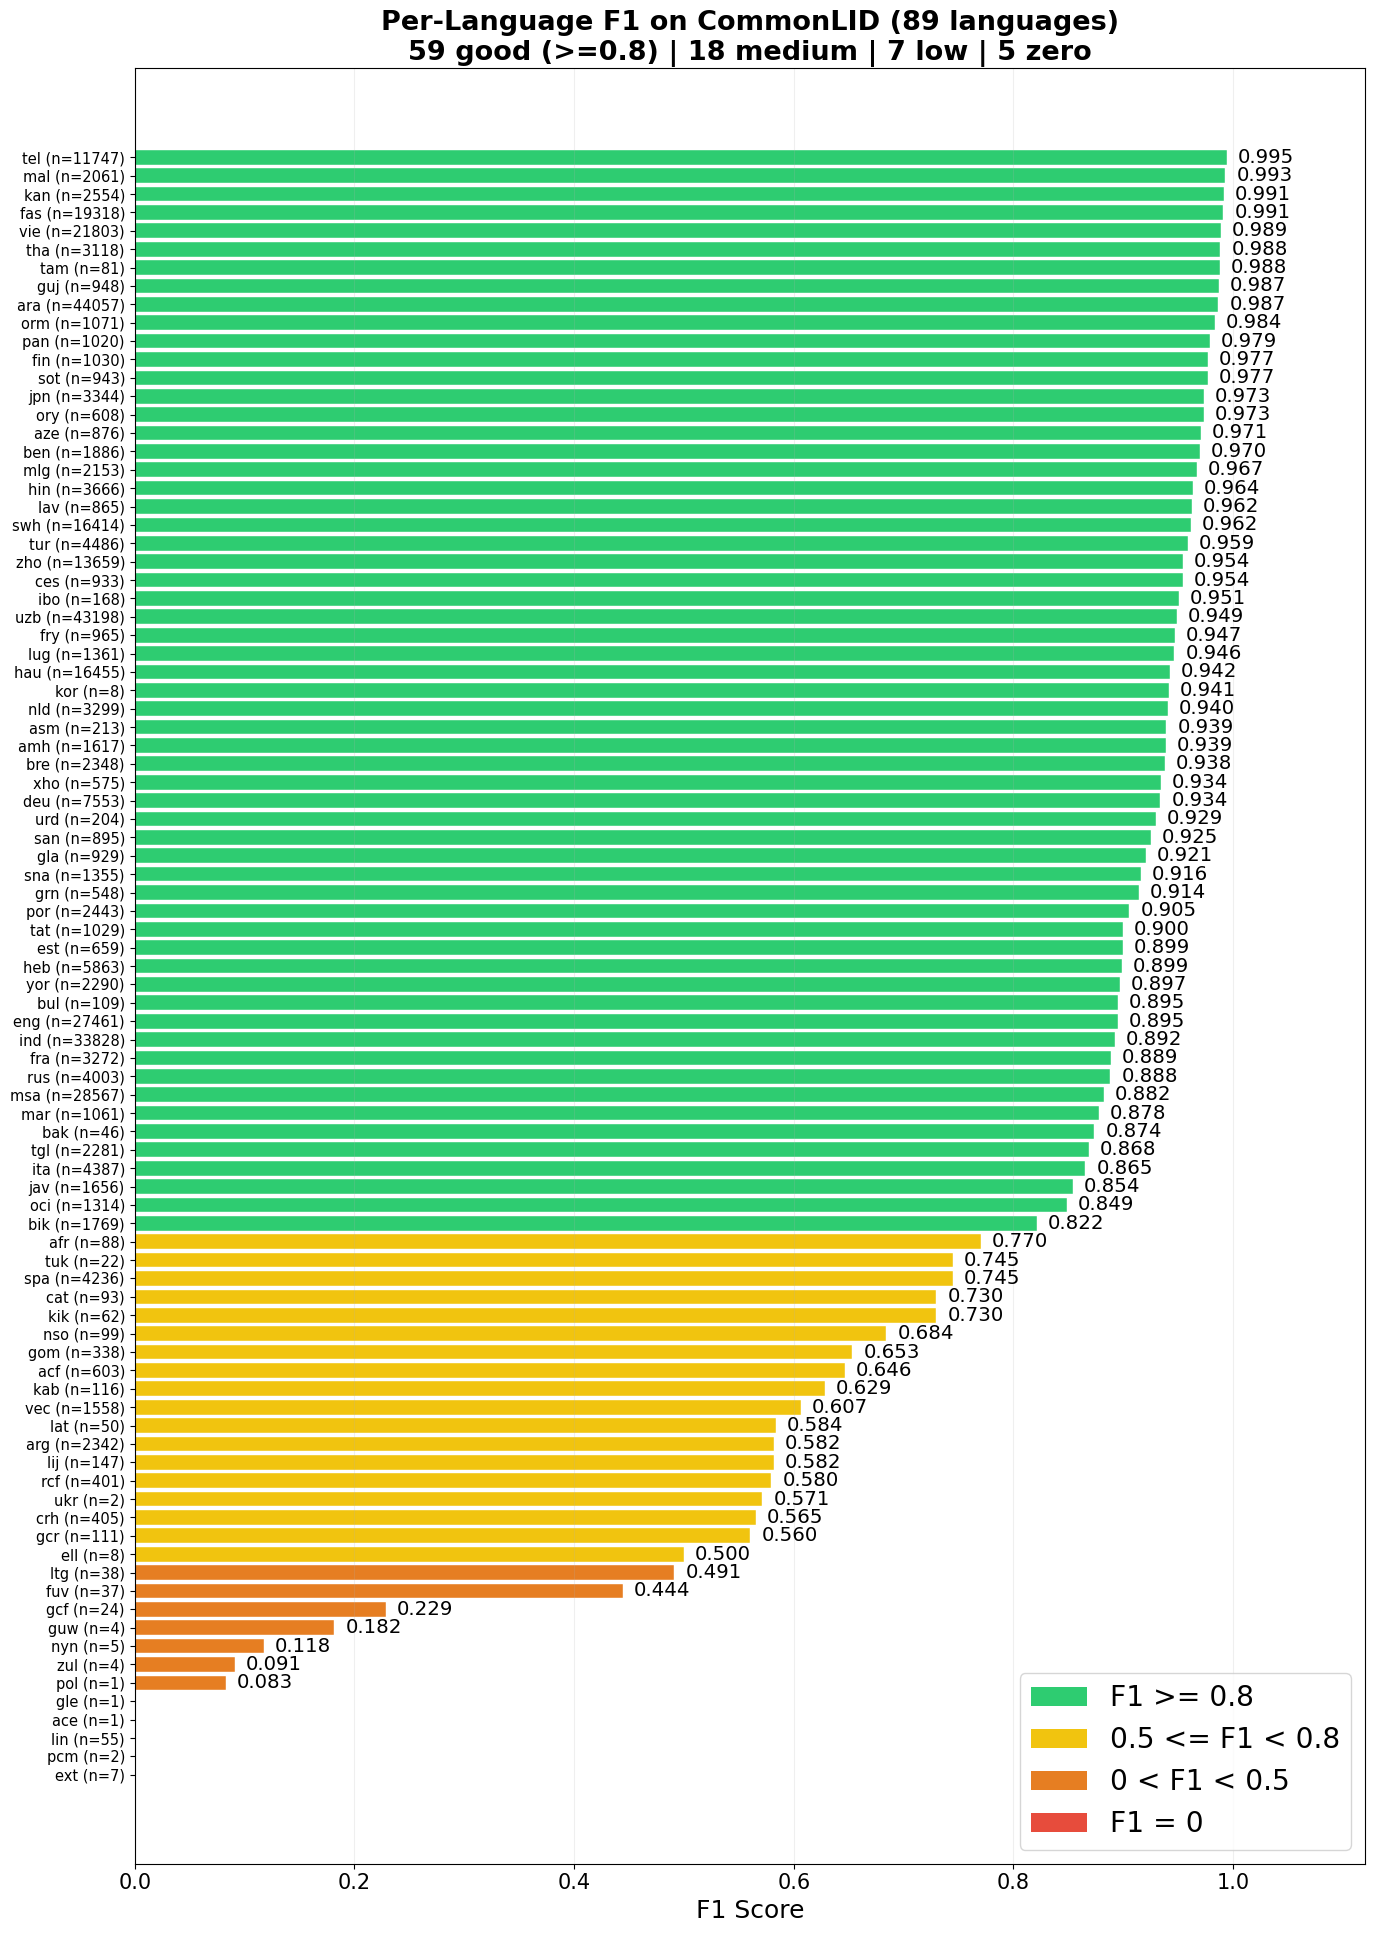

Saved to perlang_f1.png


In [3]:
# Filter to languages with >0 samples in ground truth
gt = lang_df[lang_df["n_samples"] > 0].copy()
gt = gt.sort_values("f1", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, max(12, len(gt) * 0.22)))

colors = []
for _, row in gt.iterrows():
    if row["f1"] == 0:
        colors.append("#e74c3c")
    elif row["f1"] < 0.5:
        colors.append("#e67e22")
    elif row["f1"] < 0.8:
        colors.append("#f1c40f")
    else:
        colors.append("#2ecc71")

bars = ax.barh(range(len(gt)), gt["f1"], color=colors, edgecolor="white", linewidth=0.3)

# Labels: lang code + sample count
ylabels = [f"{row['lang']} (n={row['n_samples']})" for _, row in gt.iterrows()]
ax.set_yticks(range(len(gt)))
ax.set_yticklabels(ylabels, fontsize=10.5)

# Value labels
for i, (_, row) in enumerate(gt.iterrows()):
    if row["f1"] > 0:
        ax.text(row["f1"] + 0.01, i, f"{row['f1']:.3f}", va="center", fontsize=14.25)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2ecc71", label="F1 >= 0.8"),
    Patch(facecolor="#f1c40f", label="0.5 <= F1 < 0.8"),
    Patch(facecolor="#e67e22", label="0 < F1 < 0.5"),
    Patch(facecolor="#e74c3c", label="F1 = 0"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=20.25)

n_good = len(gt[gt["f1"] >= 0.8])
n_mid = len(gt[(gt["f1"] >= 0.5) & (gt["f1"] < 0.8)])
n_low = len(gt[(gt["f1"] > 0) & (gt["f1"] < 0.5)])
n_zero = len(gt[gt["f1"] == 0])

ax.set_xlabel("F1 Score", fontsize=18)
ax.set_title(f"Per-Language F1 on CommonLID ({len(gt)} languages)\n"
             f"{n_good} good (>=0.8) | {n_mid} medium | {n_low} low | {n_zero} zero",
             fontsize=19.5, fontweight="bold")
ax.set_xlim(0, 1.12)
ax.grid(True, axis="x", alpha=0.2)

plt.tight_layout()
plt.savefig("perlang_f1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to perlang_f1.png")

## Top Confusion Pairs

The most common misclassifications. `und` = CLD2 returned "Unknown" (short/ambiguous text).

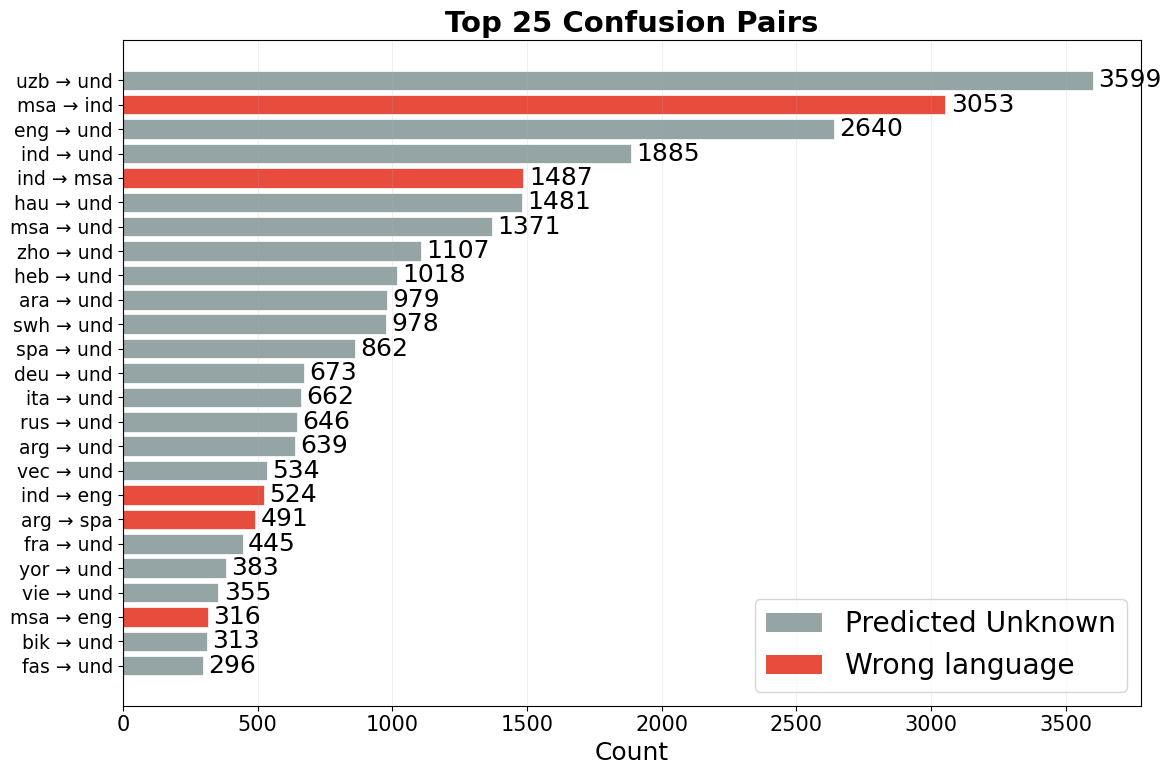

Saved to confusion_lid.png


In [4]:
top_conf = conf_df.head(25).copy()
top_conf["label"] = top_conf["true_lang"] + " \u2192 " + top_conf["pred_lang"]
top_conf = top_conf.iloc[::-1]  # reverse for horizontal bar

fig, ax = plt.subplots(figsize=(12, 8))

colors = ["#95a5a6" if row["pred_lang"] == "und" else "#e74c3c"
          for _, row in top_conf.iterrows()]

ax.barh(range(len(top_conf)), top_conf["count"], color=colors,
        edgecolor="white", linewidth=0.5)
ax.set_yticks(range(len(top_conf)))
ax.set_yticklabels(top_conf["label"], fontsize=13.5)

for i, val in enumerate(top_conf["count"]):
    ax.text(val + 20, i, str(val), va="center", fontsize=18)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#95a5a6", label="Predicted Unknown"),
    Patch(facecolor="#e74c3c", label="Wrong language"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=20.25)

ax.set_xlabel("Count", fontsize=18)
ax.set_title("Top 25 Confusion Pairs", fontsize=21, fontweight="bold")
ax.grid(True, axis="x", alpha=0.2)

plt.tight_layout()
plt.savefig("confusion_lid.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to confusion_lid.png")

## Summary Statistics

In [5]:
gt = lang_df[lang_df["n_samples"] > 0].copy()
total_samples = gt["n_samples"].sum()

print("=" * 60)
print("CommonLID Evaluation Summary")
print("=" * 60)
print(f"Total samples:        {total_samples:,}")
print(f"Total languages:      {len(gt)}")
print(f"Supported languages:  {len(gt[gt['supported'] == 'yes'])}")
print()
print(f"Macro F1:  {df.iloc[0]['macro_f1']:.4f} -> {df.iloc[-1]['macro_f1']:.4f}  "
      f"(+{(df.iloc[-1]['macro_f1'] - df.iloc[0]['macro_f1']):.4f})")
print(f"Micro F1:  {df.iloc[0]['micro_f1']:.4f} -> {df.iloc[-1]['micro_f1']:.4f}  "
      f"(+{(df.iloc[-1]['micro_f1'] - df.iloc[0]['micro_f1']):.4f})")
print()

# Baselines comparison
print("Comparison with baselines:")
for _, row in baselines.iterrows():
    print(f"  {row['model']:<15} macro={row['macro_f1']:.4f}  micro={row['micro_f1']:.4f}")
print()

# Top/bottom languages by F1
gt_with_f1 = gt[gt["n_samples"] >= 10].sort_values("f1", ascending=False)
print("Top 10 languages (by F1, n>=10):")
for _, row in gt_with_f1.head(10).iterrows():
    print(f"  {row['lang']:<8} F1={row['f1']:.4f}  P={row['precision']:.3f}  "
          f"R={row['recall']:.3f}  n={row['n_samples']}")

print(f"\nBottom 10 languages (by F1, n>=10):")
for _, row in gt_with_f1.tail(10).iterrows():
    print(f"  {row['lang']:<8} F1={row['f1']:.4f}  P={row['precision']:.3f}  "
          f"R={row['recall']:.3f}  n={row['n_samples']}")

# Biggest error sources
print(f"\nTop 10 confusion pairs:")
for _, row in conf_df.head(10).iterrows():
    print(f"  {row['true_lang']:>5} -> {row['pred_lang']:<5}  {row['count']:>5}")

CommonLID Evaluation Summary
Total samples:        373,230
Total languages:      89
Supported languages:  89

Macro F1:  0.4650 -> 0.7676  (+0.3026)
Micro F1:  0.8694 -> 0.9330  (+0.0636)

Comparison with baselines:
  cld2-baseline   macro=0.4650  micro=0.8694
  cld2-extended   macro=0.7676  micro=0.9330
  glotlid         macro=0.7354  micro=0.8015
  openlid-v3      macro=0.6263  micro=0.7683

Top 10 languages (by F1, n>=10):
  tel      F1=0.9946  P=1.000  R=0.989  n=11747
  mal      F1=0.9929  P=1.000  R=0.986  n=2061
  kan      F1=0.9913  P=1.000  R=0.983  n=2554
  fas      F1=0.9910  P=1.000  R=0.982  n=19318
  vie      F1=0.9888  P=1.000  R=0.978  n=21803
  tha      F1=0.9883  P=0.998  R=0.979  n=3118
  tam      F1=0.9878  P=0.976  R=1.000  n=81
  guj      F1=0.9872  P=1.000  R=0.975  n=948
  ara      F1=0.9865  P=1.000  R=0.974  n=44057
  orm      F1=0.9835  P=0.996  R=0.971  n=1071

Bottom 10 languages (by F1, n>=10):
  lat      F1=0.5839  P=0.460  R=0.800  n=50
  arg      F1=0.5

## New Languages Added

Performance of the 17 new languages added to CLD2 via quadgram table generation.

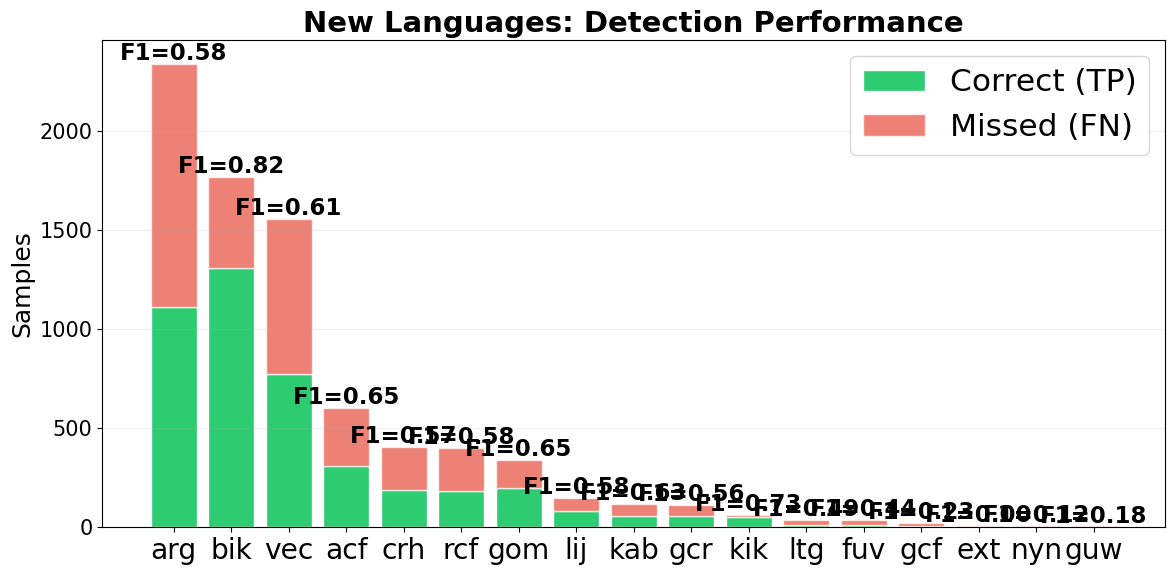

Saved to new_langs.png

Lang    Samples     TP     FP     FN      P      R     F1
-------------------------------------------------------
arg        2342   1112    367   1230  0.752  0.475  0.582
bik        1769   1308    107    461  0.924  0.739  0.822
vec        1558    775    222    783  0.777  0.497  0.607
acf         603    307     40    296  0.885  0.509  0.646
crh         405    188     72    217  0.723  0.464  0.565
rcf         401    184     50    217  0.786  0.459  0.580
gom         338    197     68    141  0.743  0.583  0.653
lij         147     80     48     67  0.625  0.544  0.582
kab         116     55      4     61  0.932  0.474  0.629
gcr         111     58     38     53  0.604  0.522  0.560
kik          62     50     25     12  0.667  0.806  0.730
ltg          38     14      5     24  0.737  0.368  0.491
fuv          37     12      5     25  0.706  0.324  0.444
gcf          24      4      7     20  0.364  0.167  0.229
ext           7      0      5      7  0.000  0.000

In [6]:
new_langs = ["arg", "vec", "bik", "acf", "crh", "rcf", "gom",
             "lij", "kab", "gcr", "kik", "ltg", "fuv", "gcf",
             "ext", "nyn", "guw"]

new_df = lang_df[lang_df["lang"].isin(new_langs) & (lang_df["n_samples"] > 0)].copy()
new_df = new_df.sort_values("n_samples", ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(new_df))

# Stacked: TP (green), FN (red)
ax.bar(x, new_df["tp"], color="#2ecc71", label="Correct (TP)", edgecolor="white")
ax.bar(x, new_df["fn"], bottom=new_df["tp"], color="#e74c3c",
       label="Missed (FN)", edgecolor="white", alpha=0.7)

# F1 annotations
for i, (_, row) in enumerate(new_df.iterrows()):
    total = row["tp"] + row["fn"]
    ax.text(i, total + 20, f"F1={row['f1']:.2f}", ha="center", fontsize=16.5, fontweight="bold")

ax.set_xticks(list(x))
ax.set_xticklabels(new_df["lang"], fontsize=20.25)
ax.set_ylabel("Samples", fontsize=18)
ax.set_title("New Languages: Detection Performance", fontsize=21, fontweight="bold")
ax.legend(loc="upper right", fontsize=22.5)
ax.grid(True, axis="y", alpha=0.2)

plt.tight_layout()
plt.savefig("new_langs.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to new_langs.png")

# Table
print(f"\n{'Lang':<6} {'Samples':>8} {'TP':>6} {'FP':>6} {'FN':>6} {'P':>6} {'R':>6} {'F1':>6}")
print("-" * 55)
for _, row in new_df.iterrows():
    print(f"{row['lang']:<6} {row['n_samples']:>8} {row['tp']:>6} {row['fp']:>6} {row['fn']:>6} "
          f"{row['precision']:>6.3f} {row['recall']:>6.3f} {row['f1']:>6.3f}")